In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, pairwise_distances_argmin
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
CSV_URL = (
    "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
    "master/Machine%20Learning%20A-Z%20Template%20Folder/"
    "Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/"
    "Mall_Customers.csv"
)
CSV_PATH = "Mall_Customers.csv"

urllib.request.urlretrieve(CSV_URL, CSV_PATH)

('Mall_Customers.csv', <http.client.HTTPMessage at 0x267d98f2450>)

In [6]:
df = pd.read_csv(CSV_PATH)

df.columns = ["CustomerID", "Gender", "Age", "Annual_Income_k", "Spending_Score"]

In [7]:
df.describe()

,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

CustomerID         0
Gender             0
Age                0
Annual_Income_k    0
Spending_Score     0
dtype: int64

In [9]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

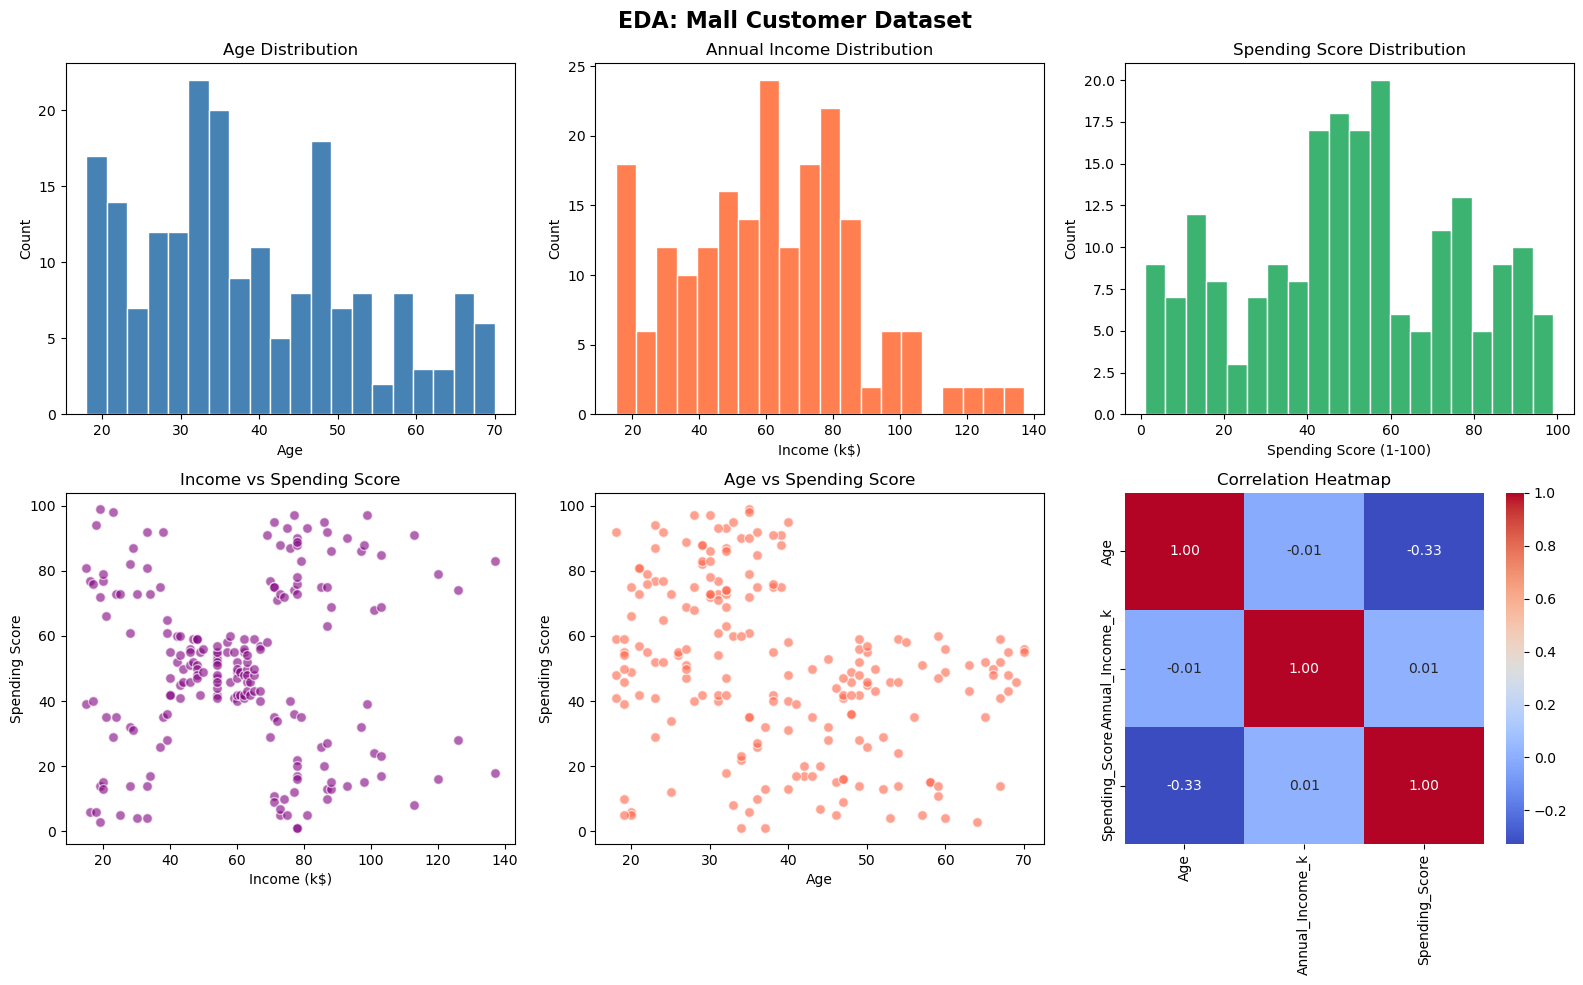

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("EDA: Mall Customer Dataset", fontsize=16, fontweight="bold")
 
axes[0, 0].hist(df["Age"], bins=20, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age"); axes[0, 0].set_ylabel("Count")
 
axes[0, 1].hist(df["Annual_Income_k"], bins=20, color="coral", edgecolor="white")
axes[0, 1].set_title("Annual Income Distribution")
axes[0, 1].set_xlabel("Income (k$)"); axes[0, 1].set_ylabel("Count")
 
axes[0, 2].hist(df["Spending_Score"], bins=20, color="mediumseagreen", edgecolor="white")
axes[0, 2].set_title("Spending Score Distribution")
axes[0, 2].set_xlabel("Spending Score (1-100)"); axes[0, 2].set_ylabel("Count")
 
axes[1, 0].scatter(df["Annual_Income_k"], df["Spending_Score"],
                   alpha=0.6, color="purple", edgecolors="white", s=50)
axes[1, 0].set_title("Income vs Spending Score")
axes[1, 0].set_xlabel("Income (k$)"); axes[1, 0].set_ylabel("Spending Score")
 
axes[1, 1].scatter(df["Age"], df["Spending_Score"],
                   alpha=0.6, color="tomato", edgecolors="white", s=50)
axes[1, 1].set_title("Age vs Spending Score")
axes[1, 1].set_xlabel("Age"); axes[1, 1].set_ylabel("Spending Score")
 
numeric_cols = df[["Age", "Annual_Income_k", "Spending_Score"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", ax=axes[1, 2], fmt=".2f")
axes[1, 2].set_title("Correlation Heatmap")
 
plt.tight_layout()

In [11]:
df_clean = df.drop(columns=["CustomerID", "Gender"])


In [12]:
dups = df_clean.duplicated().sum()


In [13]:
for col in df_clean.columns:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f"PC1: {var1:.1f}%  |  PC2: {var2:.1f}%  |  Total: {var1+var2:.1f}%")

PC1: 44.3%  |  PC2: 33.3%  |  Total: 77.6%


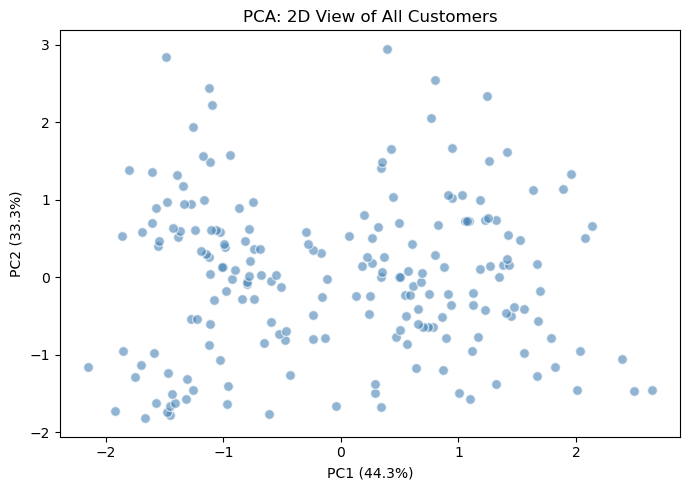

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color="steelblue", edgecolors="white", s=50)
ax.set_xlabel(f"PC1 ({var1:.1f}%)"); ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.set_title("PCA: 2D View of All Customers")
plt.tight_layout()

In [17]:
inertia_values = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    print(f"  K={k}  Inertia={km.inertia_:.1f}")

c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

  K=1  Inertia=600.0
  K=2  Inertia=389.4
  K=3  Inertia=295.2
  K=4  Inertia=205.2
  K=5  Inertia=168.2
  K=6  Inertia=133.9
  K=7  Inertia=117.0
  K=8  Inertia=103.9


c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

  K=9  Inertia=93.1
  K=10  Inertia=82.4


c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [18]:
best_k = 5
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)
km_score = silhouette_score(X_scaled, km_labels)
print(f"\nChosen K = {best_k}  |  K-Means Silhouette Score: {km_score:.4f}")


Chosen K = 5  |  K-Means Silhouette Score: 0.4166


c:\Users\muabd\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


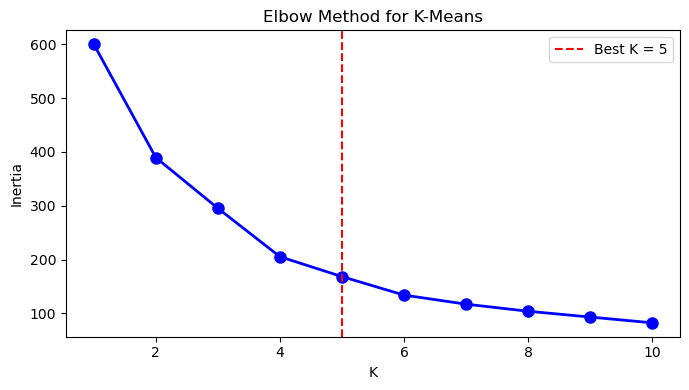

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertia_values, "bo-", linewidth=2, markersize=8)
ax.axvline(x=best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
ax.set_xlabel("K"); ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for K-Means"); ax.legend()
plt.tight_layout()

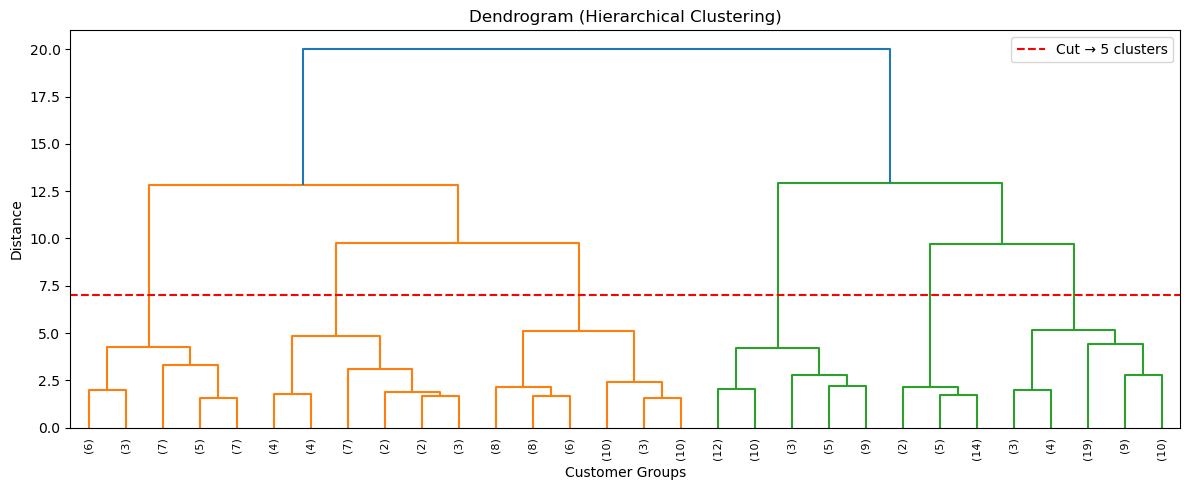

In [20]:
linkage_matrix = linkage(X_scaled, method="ward")
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title("Dendrogram (Hierarchical Clustering)")
ax.set_xlabel("Customer Groups"); ax.set_ylabel("Distance")
ax.axhline(y=7, color="red", linestyle="--", label="Cut → 5 clusters")
ax.legend()
plt.tight_layout()

In [21]:
hc = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)
hc_score = silhouette_score(X_scaled, hc_labels)
print(f"Hierarchical Silhouette Score: {hc_score:.4f}")

Hierarchical Silhouette Score: 0.3900


In [22]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, 4])[::-1]

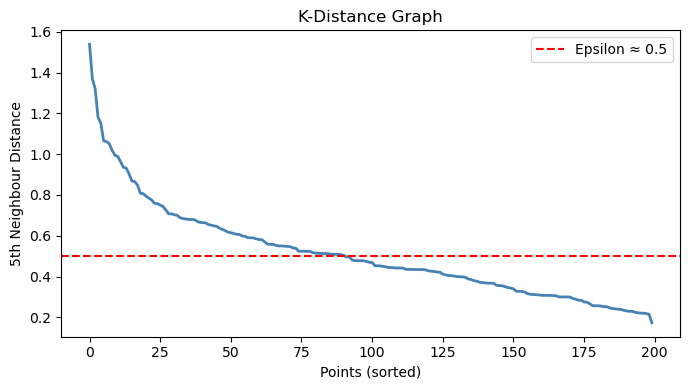

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_distances, color="steelblue", linewidth=2)
ax.axhline(y=0.5, color="red", linestyle="--", label="Epsilon ≈ 0.5")
ax.set_xlabel("Points (sorted)"); ax.set_ylabel("5th Neighbour Distance")
ax.set_title("K-Distance Graph"); ax.legend()
plt.tight_layout()

In [24]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels) - {-1})
n_noise_db = list(db_labels).count(-1)
print(f"Clusters: {n_clusters_db}  |  Noise points: {n_noise_db}")

Clusters: 6  |  Noise points: 60


In [25]:
if n_clusters_db >= 2:
    mask = db_labels != -1
    db_score = silhouette_score(X_scaled[mask], db_labels[mask])
else:
    db_score = -1.0
print(f"DBSCAN Silhouette Score: {db_score:.4f}")

DBSCAN Silhouette Score: 0.4817


C:\Users\muabd\AppData\Local\Temp\ipykernel_7832\430436771.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(palette, len(np.unique(labels)))
C:\Users\muabd\AppData\Local\Temp\ipykernel_7832\430436771.py:14: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[i].scatter(X_pca[mask, 0], X_pca[mask, 1],


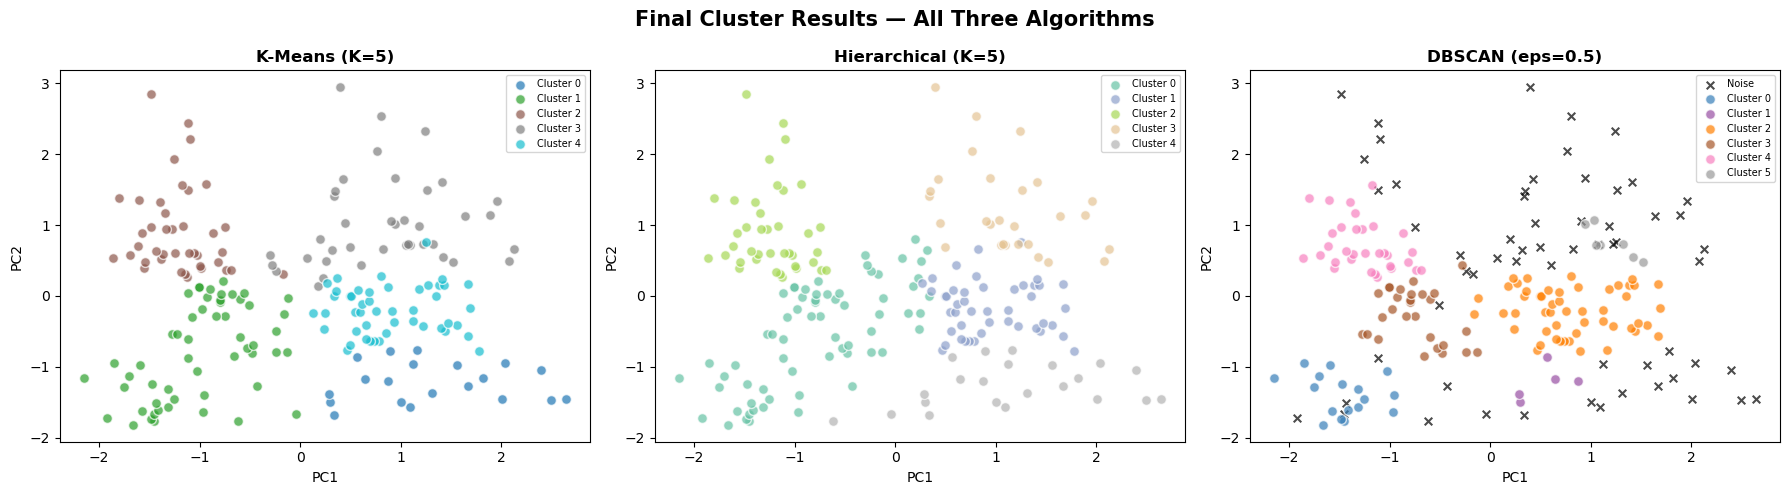

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Final Cluster Results — All Three Algorithms", fontsize=15, fontweight="bold")
 
for i, (title, labels, palette) in enumerate([
    (f"K-Means (K={best_k})",        km_labels, "tab10"),
    (f"Hierarchical (K={best_k})",   hc_labels, "Set2"),
    (f"DBSCAN (eps=0.5)",            db_labels, "Set1"),
]):
    cmap = plt.cm.get_cmap(palette, len(np.unique(labels)))
    for j, label in enumerate(np.unique(labels)):
        mask = labels == label
        colour = "black" if label == -1 else cmap(j)
        lbl    = "Noise" if label == -1 else f"Cluster {label}"
        axes[i].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c=[colour], marker="x" if label==-1 else "o",
                        s=30 if label==-1 else 50, alpha=0.7,
                        label=lbl, edgecolors="white" if label!=-1 else "none")
    axes[i].set_title(title, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("PC1"); axes[i].set_ylabel("PC2")
    axes[i].legend(fontsize=7, loc="upper right")
 
plt.tight_layout()

In [27]:
print("STEP 10: FINAL SUMMARY TABLE")
print("=" * 60)
 
summary = pd.DataFrame({
    "Algorithm":        ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette_Score": [round(km_score,4), round(hc_score,4), round(db_score,4)],
    "Clusters_Found":   [len(np.unique(km_labels)), len(np.unique(hc_labels)), n_clusters_db],
    "Noise_Points":     [0, 0, n_noise_db],
})
print(summary.to_string(index=False))
 
best_idx  = summary["Silhouette_Score"].idxmax()
best_algo = summary.loc[best_idx, "Algorithm"]
print(f"\nBest Algorithm: {best_algo}  (Score = {summary.loc[best_idx,'Silhouette_Score']})")

STEP 10: FINAL SUMMARY TABLE
   Algorithm  Silhouette_Score  Clusters_Found  Noise_Points
     K-Means            0.4166               5             0
Hierarchical            0.3900               5             0
      DBSCAN            0.4817               6            60

Best Algorithm: DBSCAN  (Score = 0.4817)


In [28]:
best_labels = {"K-Means": km_labels, "Hierarchical": hc_labels, "DBSCAN": db_labels}[best_algo]
output_df = df_clean.copy()
output_df["Cluster_Label"] = best_labels
output_df.to_csv("clustered_customers.csv", index=False)
print(f"Saved: clustered_customers.csv  ({len(output_df)} rows)")
 
reloaded = pd.read_csv("clustered_customers.csv")
print(f"Reloaded shape: {reloaded.shape}")
print("Cluster counts:\n", reloaded["Cluster_Label"].value_counts().sort_index())

Saved: clustered_customers.csv  (200 rows)
Reloaded shape: (200, 4)
Cluster counts:
 Cluster_Label
-1    60
 0    17
 1     5
 2    51
 3    28
 4    32
 5     7
Name: count, dtype: int64


In [ ]:
new_customers = pd.DataFrame({
    "Age":             [22, 45, 30, 55, 35],
    "Annual_Income_k": [20, 80, 50, 100, 60],
    "Spending_Score":  [90, 20, 50, 85, 45],
})
print("New customers:"); print(new_customers.to_string(index=False))
 
new_scaled = scaler.transform(new_customers)   
 
if best_algo == "K-Means":
    new_labels = km_final.predict(new_scaled)
else:
    non_noise = best_labels != -1 if best_algo == "DBSCAN" else np.ones(len(best_labels), bool)
    centres = np.array([
        X_scaled[best_labels == c].mean(axis=0)
        for c in np.unique(best_labels[best_labels != -1]) if best_algo == "DBSCAN"
        or True
    ])
    unique_lbls = [l for l in np.unique(best_labels) if l != -1]
    centres = np.array([X_scaled[best_labels == l].mean(axis=0) for l in unique_lbls])
    new_labels = pairwise_distances_argmin(new_scaled, centres)
 
new_customers["Assigned_Cluster"] = new_labels
print("\nWith assigned clusters:"); print(new_customers.to_string(index=False))

New customers:
 Age  Annual_Income_k  Spending_Score
  22               20              90
  45               80              20
  30               50              50
  55              100              85
  35               60              45

With assigned clusters:
 Age  Annual_Income_k  Spending_Score  Assigned_Cluster
  22               20              90                 0
  45               80              20                 5
  30               50              50                 3
  55              100              85                 4
  35               60              45                 3
